In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
from scipy.stats import randint

# Suppress all warnings
warnings.filterwarnings('ignore')


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv


**Loading the dataset**

In [2]:
import pandas as pd
file_path_train = '/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv'
train_df = pd.read_csv(file_path_train)


file_path_test = '/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv'
df_test = pd.read_csv(file_path_test)

In [3]:
# Basic overview of the dataset
print("Shape of the dataset:", train_df.shape)

# Data types of each column
print("\nColumn data types:")
print(train_df.dtypes)

# Check for missing values
print("\nMissing values:")
print(train_df.isnull().sum())




Shape of the dataset: (116023, 52)

Column data types:
trafficSource.isTrueDirect                       object
purchaseValue                                   float64
browser                                          object
device.screenResolution                          object
trafficSource.adContent                          object
trafficSource.keyword                            object
screenSize                                       object
geoCluster                                       object
trafficSource.adwordsClickInfo.slot              object
device.mobileDeviceBranding                      object
device.mobileInputSelector                       object
userId                                            int64
trafficSource.campaign                           object
device.mobileDeviceMarketingName                 object
geoNetwork.networkDomain                         object
gclIdPresent                                      int64
device.operatingSystemVersion                    

In [4]:
print("Statistical summary of numeric features:")
print(train_df.describe())



Statistical summary of numeric features:
       purchaseValue         userId   gclIdPresent  sessionNumber  \
count   1.160230e+05  116023.000000  116023.000000  116023.000000   
mean    2.656393e+07   61094.356231       0.037019       2.691311   
std     2.051825e+08   35240.756859       0.188808      10.451613   
min     0.000000e+00       0.000000       0.000000       1.000000   
25%     0.000000e+00   30603.500000       0.000000       1.000000   
50%     0.000000e+00   61014.000000       0.000000       1.000000   
75%     0.000000e+00   91616.500000       0.000000       2.000000   
max     2.312950e+10  122276.000000       1.000000     447.000000   

       totals.visits     sessionId  trafficSource.adwordsClickInfo.page  \
count       116023.0  1.160230e+05                          4281.000000   
mean             1.0  1.493429e+09                             1.019622   
std              0.0  1.528798e+07                             0.174517   
min              1.0  1.470035e+09   

In [5]:
# Checking for missing values
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)


trafficSource.adContent                         113060
trafficSource.adwordsClickInfo.slot             111742
trafficSource.adwordsClickInfo.isVideoAd        111742
trafficSource.adwordsClickInfo.adNetworkType    111742
trafficSource.adwordsClickInfo.page             111742
trafficSource.referralPath                       73309
trafficSource.isTrueDirect                       73133
trafficSource.keyword                            71861
totals.bounces                                   68875
new_visits                                       35505
pageViews                                            8
dtype: int64

In [6]:
print("Target column - purchaseValue:")
print(train_df['purchaseValue'].describe())


Target column - purchaseValue:
count    1.160230e+05
mean     2.656393e+07
std      2.051825e+08
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.312950e+10
Name: purchaseValue, dtype: float64


<Axes: >

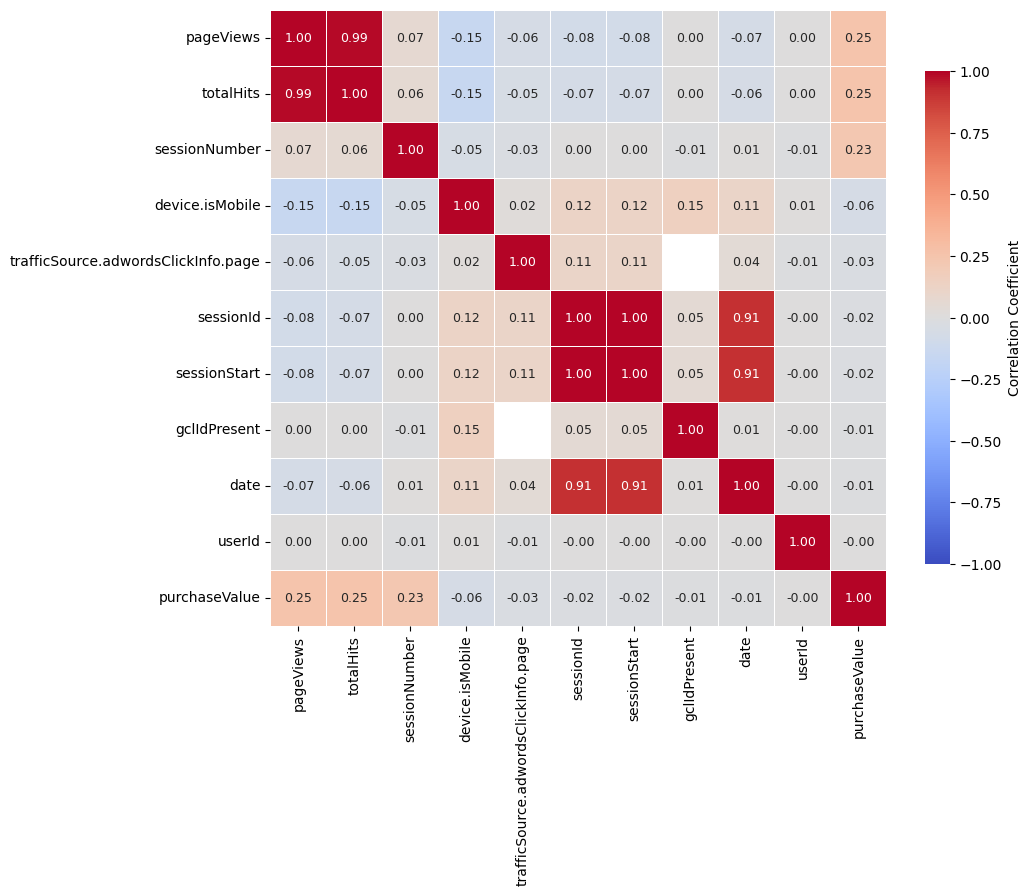

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute correlation matrix of numeric features
corr_matrix = train_df.corr(numeric_only=True).round(2)

# 2. Get top 10 features most correlated with 'purchaseValue'
target_corr = corr_matrix['purchaseValue'].drop('purchaseValue')
top_features = target_corr.abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append('purchaseValue')  # Add target to include in heatmap

# 3. Filter original DataFrame to just those features
filtered_corr = train_df[top_features].corr().round(2)

# 4. Plot clean heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    filtered_corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})



In [8]:
corr_with_target = train_df.corr(numeric_only=True)['purchaseValue'].sort_values(ascending=False)
print("Top correlated features:\n", corr_with_target.head(10))


Top correlated features:
 purchaseValue                          1.000000
totalHits                              0.251651
pageViews                              0.248454
sessionNumber                          0.230585
userId                                -0.003469
gclIdPresent                          -0.005652
date                                  -0.010338
sessionStart                          -0.018537
sessionId                             -0.018537
trafficSource.adwordsClickInfo.page   -0.025839
Name: purchaseValue, dtype: float64


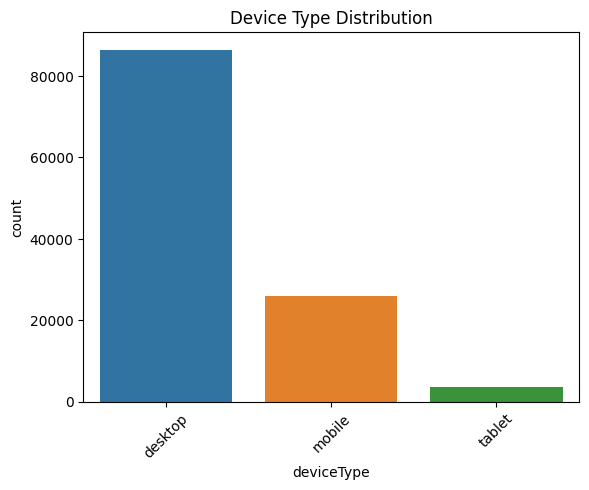

In [9]:
sns.countplot(data=train_df, x='deviceType')
plt.title("Device Type Distribution")
plt.xticks(rotation=45)
plt.show()


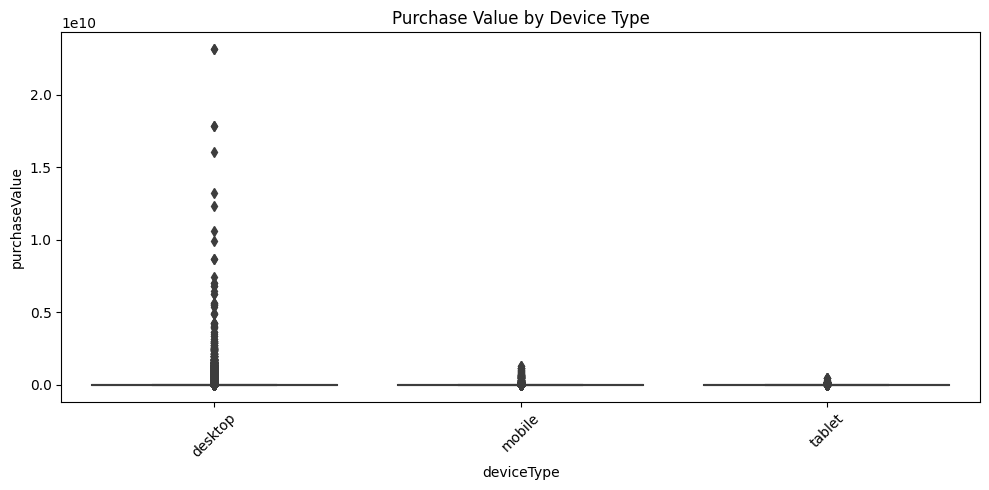

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df, x='deviceType', y='purchaseValue')
plt.title("Purchase Value by Device Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


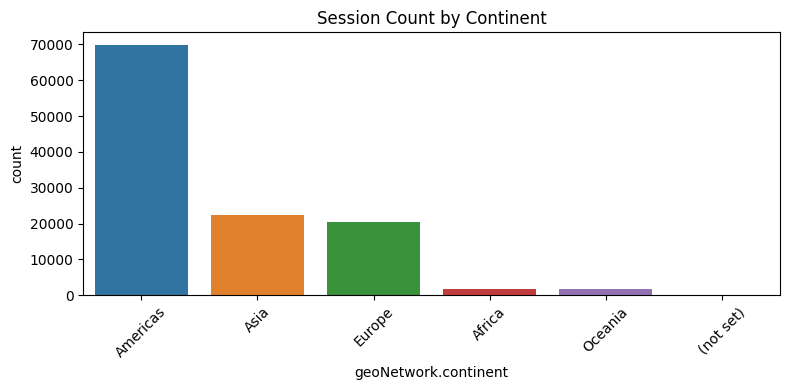

In [11]:
#Countplot: Frequency of Sessions by geoNetwork.continent

plt.figure(figsize=(8, 4))
sns.countplot(data=train_df, x='geoNetwork.continent', order=train_df['geoNetwork.continent'].value_counts().index)
plt.title("Session Count by Continent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


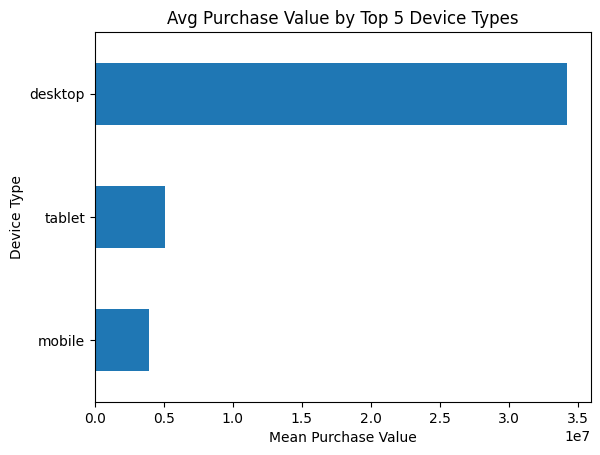

In [12]:
top_devices = train_df['deviceType'].value_counts().head(5).index
device_mean = train_df[train_df['deviceType'].isin(top_devices)].groupby('deviceType')['purchaseValue'].mean().sort_values()

device_mean.plot(kind='barh')
plt.title("Avg Purchase Value by Top 5 Device Types")
plt.xlabel("Mean Purchase Value")
plt.ylabel("Device Type")
plt.show()


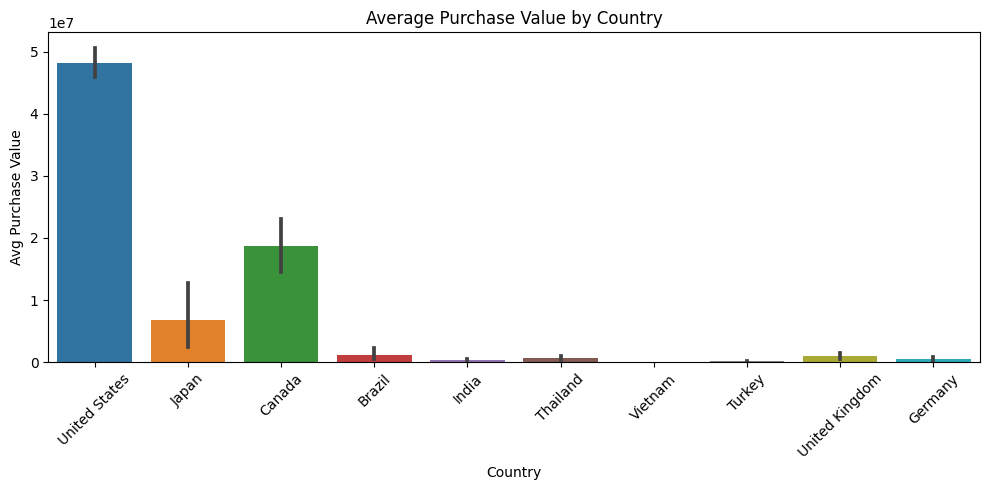

In [13]:
top_countries = train_df['locationCountry'].value_counts().head(10).index

plt.figure(figsize=(10, 5))
sns.barplot(
    data=train_df[train_df['locationCountry'].isin(top_countries)],
    x='locationCountry',
    y='purchaseValue',
    estimator='mean'
)
plt.title("Average Purchase Value by Country")
plt.ylabel("Avg Purchase Value")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Few insights from EDA

- `purchaseValue` is extremely skewed — almost all users have 0 purchases.
- Correlations with `purchaseValue` are very weak (max ~0.25), mainly from `totalHits`, `pageViews`, and `sessionNumber`.
- Most AdWords fields have over 90% missing data, reflecting sparse marketing tracking.
- **Americas dominate sessions**, accounting for the bulk of user traffic.
- **United States shows by far the highest average purchase value**, followed by Canada and Japan.
- Mobile users tend to have slightly lower purchases (`device.isMobile` shows slight negative correlation).


# Data processing

## Data cleaning and feature engineering

In [14]:
#preprocessing

train_df = train_df[~train_df['purchaseValue'].eq(train_df['purchaseValue'].max())]




columns_to_remove = [
    'device.language',
    'device.mobileDeviceModel',
    'socialEngagementType',
    'browserMajor',
    'date',
    'totalHits',
    'sessionstart'
]


train_df_dropped = train_df.drop(columns=[col for col in columns_to_remove if col in train_df.columns])
df_test_dropped = df_test.drop(columns=[col for col in columns_to_remove if col in df_test.columns])




train_df['sessionTime'] = pd.to_datetime(train_df['sessionId'], unit='s')
df_test['sessionTime'] = pd.to_datetime(df_test['sessionId'], unit='s')


for df in [train_df, df_test]:
    df['session_hour'] = df['sessionTime'].dt.hour
    df['session_dayofweek'] = df['sessionTime'].dt.dayofweek  # Monday=0
    df['session_is_weekend'] = (df['session_dayofweek'] >= 5).astype(int)
    df['session_month'] = df['sessionTime'].dt.month
    df['session_day'] = df['sessionTime'].dt.day


[df.drop(columns=['sessionTime'], inplace=True) for df in [train_df, df_test]]



train_test_joined = pd.concat([train_df, df_test], keys=['train', 'test'])

## Imputation and Encoding 

In [15]:
# Impute numeric
train_test_joined.update(
    pd.DataFrame(
        SimpleImputer(strategy='median').fit_transform(train_test_joined.select_dtypes(include='number')),
        columns=train_test_joined.select_dtypes(include='number').columns,
        index=train_test_joined.index
    )
)


categorical_cols = train_test_joined.select_dtypes(include=['object', 'category']).columns


for col in categorical_cols:
    train_test_joined[col] = train_test_joined[col].astype(str)

imputer = SimpleImputer(strategy='constant', fill_value='missing')
train_test_joined[categorical_cols] = imputer.fit_transform(train_test_joined[categorical_cols])



categorical_columns = train_test_joined.select_dtypes(include=['object', 'category']).columns.tolist()

numerical_cols = train_test_joined.select_dtypes(include=['int64', 'float64']).columns.tolist()
date_cols = [col for col in train_test_joined.columns if 'date' in col.lower()]

numerical_cols = [col for col in numerical_cols if col not in date_cols]



train_df = train_test_joined.xs('train')
test_df = train_test_joined.xs('test')




# Choose categorical columns (e.g., object or category types)
cat_cols = train_df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)

    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])






## Train Test Split 

In [16]:


from sklearn.model_selection import train_test_split

# 1. Separate features and target
X = train_df.drop(columns=['purchaseValue'])
y = train_df['purchaseValue']



# 2. Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# 3. Keep full train set 
X_full = X
y_full = y

# Model Training

In [17]:


from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_full, y_full)

y_val_pred_xgb = xgb_model.predict(X_val)
r2_xgb = r2_score(y_val, y_val_pred_xgb)
print(f"XGB R2: {r2_xgb}")





# LightGBM
from lightgbm import LGBMRegressor
lgb_model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_full, y_full)

XGB R2: 0.860675975830735


LGBMRegressor(random_state=42, verbose=-1)

In [18]:


model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_full, y_full)





RandomForestRegressor(random_state=42)

In [19]:



# XGBoost validation
y_val_pred_xgb = xgb_model.predict(X_val)
r2_xgb = r2_score(y_val, y_val_pred_xgb)
mse_xgb = mean_squared_error(y_val, y_val_pred_xgb)
print(f"XGB R2: {r2_xgb:.4f}")
print(f"XGB MSE: {mse_xgb:.4f}")



# LightGBM validation
y_val_pred_lgb = lgb_model.predict(X_val)
r2_lgb = r2_score(y_val, y_val_pred_lgb)
mse_lgb = mean_squared_error(y_val, y_val_pred_lgb)
print(f"LGB R2: {r2_lgb:.4f}")
print(f"LGB MSE: {mse_lgb:.4f}")


# Random Forest validation
y_val_pred_rf = model_rf.predict(X_val)
r2_rf = r2_score(y_val, y_val_pred_rf)
mse_rf = mean_squared_error(y_val, y_val_pred_rf)
print(f"RF R2: {r2_rf:.4f}")
print(f"RF MSE: {mse_rf:.4f}")

XGB R2: 0.8607
XGB MSE: 5625912430118186.0000
LGB R2: 0.5137
LGB MSE: 19638052657106924.0000
RF R2: 0.9147
RF MSE: 3444282660212154.0000


## Model Performance Comparison (Complex & Sparse Regression Problem)

| Model | R² Score | MSE |
|-------|----------|----------------------------|
| XGB   | 0.8607   | 5,625,912,430,118,186.0000 |
| LGB   | 0.5137   | 19,638,052,657,106,924.0000 |
| RF    | 0.9147   | 3,444,282,660,212,154.0000 |

### Interpretation in Context:

- **Random Forest (RF)**
  - **Best overall performance** in both R² and MSE.
  - Shows **strong ability to capture non-linear patterns** and interactions even in sparse and noisy data.
  - RF's ensemble nature and bootstrapping likely helped handle sparsity effectively.

- **XGBoost (XGB)**
  - Performs **very well**, with a high R² of 0.8607, suggesting it captures much of the data's variance.
  - MSE is higher than RF, which may suggest **sensitivity to outliers** or overfitting some sparse regions.
  - Still a **robust choice**, especially if fine-tuned.

- **LightGBM (LGB)**
  - Struggles significantly with this data (R² = 0.5137).
  - Highest MSE indicates **poor generalization** or difficulty learning from sparse, complex features.
  - May require **extensive hyperparameter tuning** or feature engineering to improve in such a setting.

### Conclusion:
For **complex and sparse regression tasks**, **Random Forest** demonstrates the most **reliable and stable performance**, followed by **XGBoost**. **LightGBM** appears to be less suited for this specific problem without further adaptation.



## Hyperparameter Tuning

In [20]:


# Base model
base_model = RandomForestRegressor(n_estimators=100, random_state=42)
base_model.fit(X_full, y_full)

y_val_pred_base = base_model.predict(X_val)
base_r2 = r2_score(y_val, y_val_pred_base)

param_grid = {
    'n_estimators': randint(80, 120),
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2]
}


random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, 
    n_iter=15, 
    cv=3, 
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_full, y_full)



tuned_model = random_search.best_estimator_
y_val_pred_tuned = tuned_model.predict(X_val)
tuned_r2 = r2_score(y_val, y_val_pred_tuned)
print(f"Tuned R²: {tuned_r2:.4f}")

# Use tuned only if better
if tuned_r2 > base_r2:
    model = tuned_model
    
else:
    model = base_model
 

print(f"Best params: {random_search.best_params_}")



Tuned R²: 0.8903
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 83}


In [21]:



ids = test_df['id'] if 'id' in test_df.columns else range(len(test_df))
test_features = test_df.drop(columns=[col for col in ['id', 'purchaseValue'] if col in test_df.columns])


predictions = model.predict(test_features)


submission_df = pd.DataFrame({
   'id': ids,
   'purchaseValue': predictions
})


submission_df.to_csv("submission.csv", index=False)
print("submission.csv created successfully.")

submission.csv created successfully.


In [22]:

from IPython.display import FileLink
FileLink("submission.csv")

/kaggle/working/submission.csv